In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy

In [3]:
nlp = spacy.load('en_core_web_sm')

In [4]:
#dataset cleaning
df = pd.read_csv('support-ticket-classification.csv')
df.info()

print("Dataset Shape:", df.shape)
print("\nTarget Labels Distribution:")
print(df['label'].value_counts())


df['full_text'] = df['subject'].fillna('') + " " + df['text'].fillna('')
df = df.dropna(subset=['label'])
df.duplicated().sum()

FileNotFoundError: [Errno 2] No such file or directory: 'support-ticket-classification.csv'

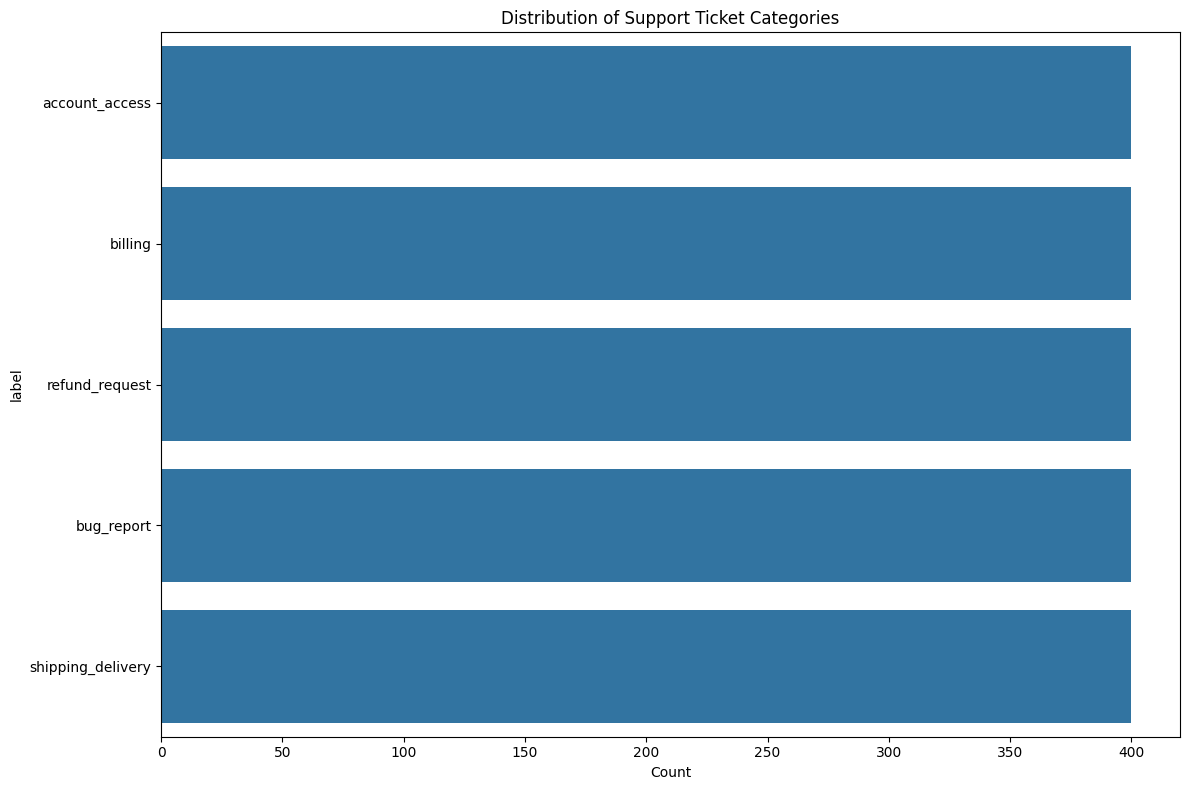

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(y=df['label'], order=df['label'].value_counts().index)
plt.title('Distribution of Support Ticket Categories')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [ ]:

#text data preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
   
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if (not token.is_stop and 
            not token.is_punct and 
            not token.is_digit and 
            len(token.lemma_) > 2):
            tokens.append(token.lemma_)
    return " ".join(tokens)

print("Preprocessing text... (This may take a minute)")
df['clean_text'] = df['full_text'].apply(preprocess_text)

Preprocessing text... (This may take a minute)


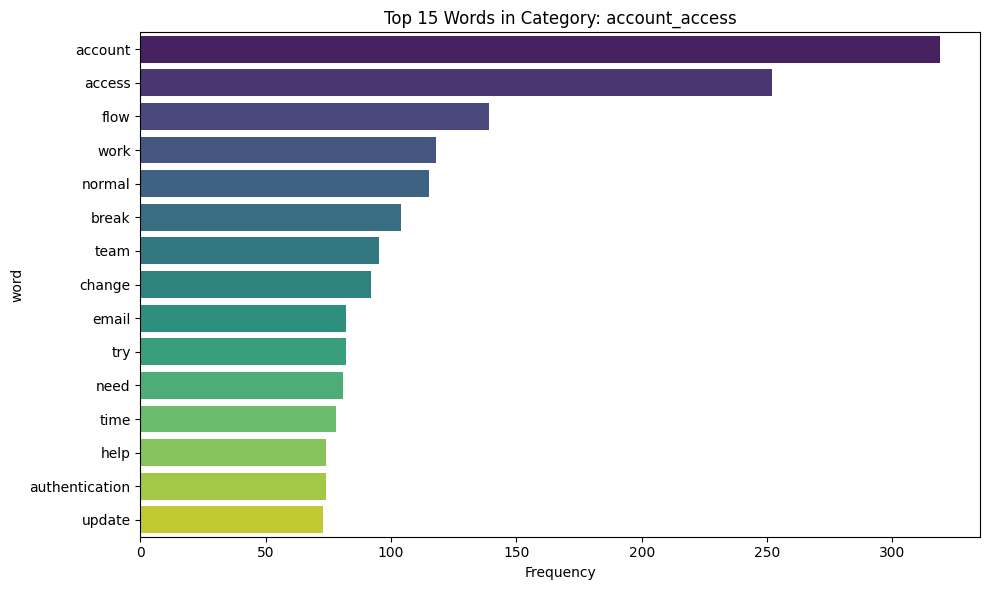

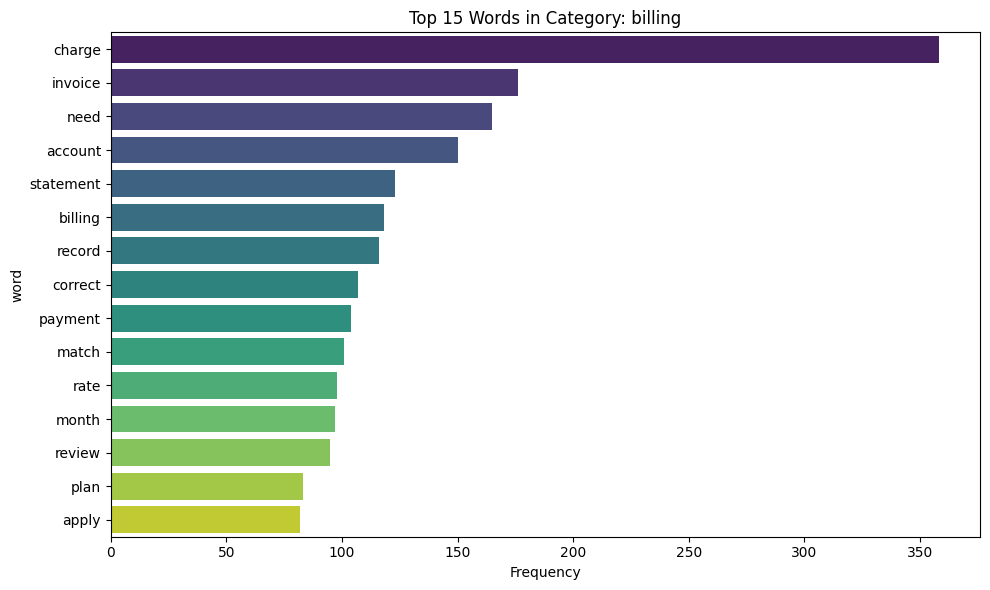

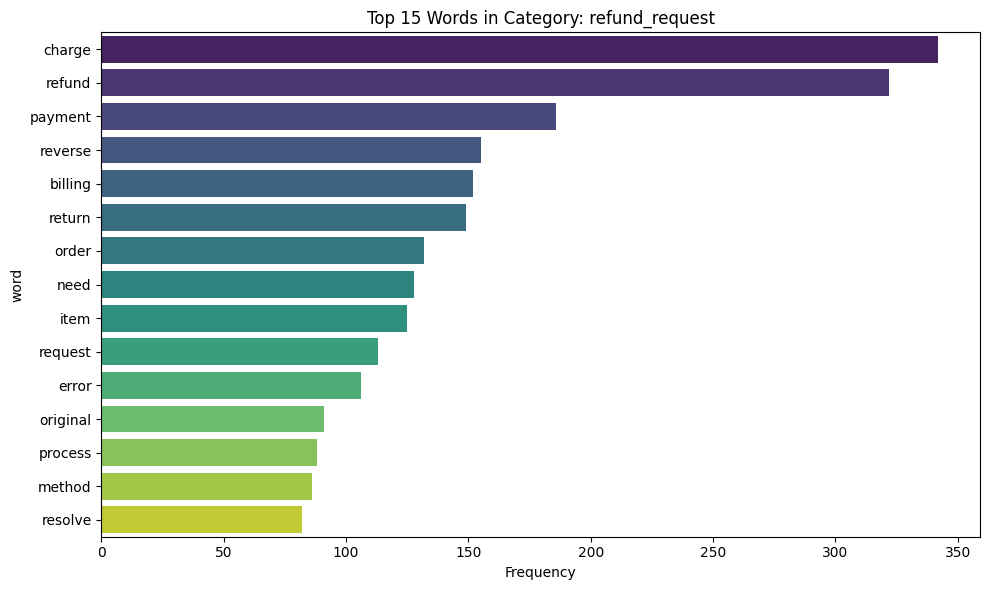

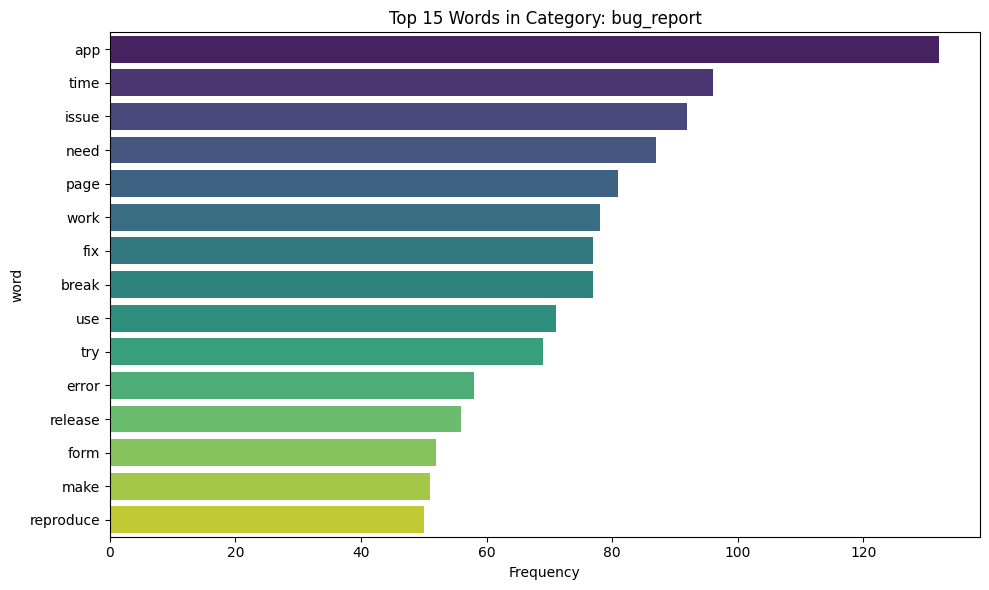

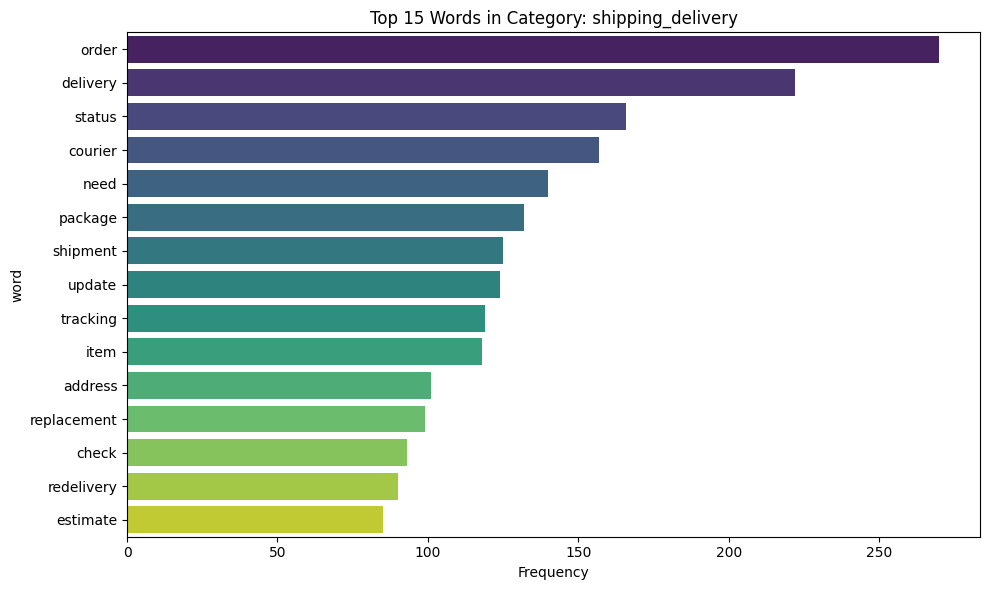

In [ ]:
#top words in each ticket category
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

def plot_top_words(category, n=15):
    subset = df[df['label'] == category]
    if len(subset) == 0:
        return
    
    vectorizer = CountVectorizer(stop_words='english', max_features=100)
    X = vectorizer.fit_transform(subset['clean_text'])
    word_freq = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()
    
    top_words = pd.DataFrame({'word': words, 'freq': word_freq}).sort_values('freq', ascending=False).head(n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='freq', y='word', data=top_words, palette='viridis')
    plt.title(f'Top {n} Words in Category: {category}')
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

major_categories = ['account_access', 'billing', 'refund_request', 'bug_report','shipping_delivery']
for cat in major_categories:
    plot_top_words(cat)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [ ]:
#split data for training and testing
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#Apply Logistic Regression model
pipelin = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=12000, stop_words='english',ngram_range=(1,5))),
    ('classifier', LogisticRegression( max_iter=1000,class_weight='balanced'))
])

pipelin.fit(X_train, y_train)
y_pred = pipelin.predict(X_test)

print("="*60)
print("FINAL MODEL ACCURACY:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

FINAL MODEL ACCURACY: 89.5 %

Classification Report:
                   precision    recall  f1-score   support

   account_access       0.86      0.95      0.90        80
          billing       0.90      0.82      0.86        80
       bug_report       0.89      0.88      0.88        80
   refund_request       0.88      0.86      0.87        80
shipping_delivery       0.94      0.96      0.95        80

         accuracy                           0.90       400
        macro avg       0.90      0.90      0.89       400
     weighted avg       0.90      0.90      0.89       400



In [ ]:
#Apply support vector machine
from sklearn.svm import LinearSVC
svm_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=12000, stop_words='english', ngram_range=(1,3))),
    ('classifier', LinearSVC())
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("Linear SVM Accuracy:", round(accuracy_score(y_test, y_pred_svm)*100, 2), "%")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 90.5 %
                   precision    recall  f1-score   support

   account_access       0.88      0.95      0.92        80
          billing       0.91      0.85      0.88        80
       bug_report       0.90      0.89      0.89        80
   refund_request       0.91      0.85      0.88        80
shipping_delivery       0.93      0.99      0.96        80

         accuracy                           0.91       400
        macro avg       0.91      0.91      0.90       400
     weighted avg       0.91      0.91      0.90       400



In [ ]:
#Apply Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=12000, stop_words='english', ngram_range=(1,3))),
    ('classifier', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print("Naive Bayes Accuracy:", round(accuracy_score(y_test, y_pred_nb)*100, 2), "%")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 90.25 %
                   precision    recall  f1-score   support

   account_access       0.88      0.96      0.92        80
          billing       0.89      0.90      0.89        80
       bug_report       0.93      0.82      0.87        80
   refund_request       0.88      0.86      0.87        80
shipping_delivery       0.94      0.96      0.95        80

         accuracy                           0.90       400
        macro avg       0.90      0.90      0.90       400
     weighted avg       0.90      0.90      0.90       400



In [ ]:
#sentiment analysis pipeline
from transformers import pipeline

print("\nLoading Transformers Sentiment Pipeline...")


sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    tokenizer="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

def get_transformers_sentiment(text):

        
        result = sentiment_pipeline(text[:512])[0]
        label = result['label']
        score = result['score']
        return label.capitalize(), round(score, 4)
    

print("Analyzing sentiment with Transformers...")
df[['sentiment', 'sentiment_score']] = df['full_text'].apply(
    lambda x: pd.Series(get_transformers_sentiment(x))
)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())



Loading Transformers Sentiment Pipeline...
Analyzing sentiment with Transformers...

Sentiment Distribution:
sentiment
Negative    1961
Positive      39
Name: count, dtype: int64


In [ ]:
#test complete pipeline with custom tickets
test_tickets = [
    "I was charged twice this month and need refund immediately!",
    "My account is locked and I cannot login even after password reset",
    "The new dark mode feature works perfectly, thank you team!",
    "App keeps crashing every time I try to upload a file",
    "How do I reset my password? It's not working at all",
    "Please add bulk export feature, it would save so much time",
    "I received two identical charges on my card today",
    "Everything is working fine after the update, great job!",
]

results = []

for text in test_tickets:
    clean = preprocess_text(text)
    
    
    pred_label = pipelin.predict([clean])[0]
    pred_proba = pipelin.predict_proba([clean]).max()
    
    
    sentiment, sent_score = get_transformers_sentiment(text)
    
    results.append({
        'ticket_text': text,
        'predicted_label': pred_label,
        'label_confidence': round(pred_proba * 100, 2),
        'sentiment': sentiment,
        'sentiment_score': round(sent_score * 100, 2)
    })

test_df = pd.DataFrame(results)
test_df = test_df[test_df['label_confidence'] > 50]

print("\nCustom Test Predictions (Label Confidence > 50%):")
print(test_df)


test_df.to_csv('custom_test_predictions.csv', index=False)
df[['id', 'label', 'full_text', 'clean_text', 'sentiment', 'sentiment_score']].to_csv('ticket_analysis_final.csv', index=False)

print("\n   Files saved successfully!")
print("   - custom_test_predictions.csv")
print("   - ticket_analysis_final.csv")


Custom Test Predictions (Label Confidence > 50%):
                                         ticket_text predicted_label  \
1  My account is locked and I cannot login even a...  account_access   
2  The new dark mode feature works perfectly, tha...      bug_report   
3  App keeps crashing every time I try to upload ...      bug_report   
4  How do I reset my password? It's not working a...  account_access   
5  Please add bulk export feature, it would save ...      bug_report   

   label_confidence sentiment  sentiment_score  
1             73.40  Negative            99.61  
2             53.27  Positive            99.99  
3             84.10  Negative            99.83  
4             60.83  Negative            99.98  
5             60.38  Negative            99.77  

   Files saved successfully!
   - custom_test_predictions.csv
   - ticket_analysis_final.csv


# S.A.G.E. Model Export Section

In [ ]:

# =========================
# MODEL EXPORTS FOR S.A.G.E.
# =========================

import os
import joblib

os.makedirs("backend/ml/models", exist_ok=True)

# Export Logistic Regression Pipeline
joblib.dump(
    pipelin,
    "backend/ml/models/category_model.pkl"
)

# Export SVM Pipeline
joblib.dump(
    svm_pipeline,
    "backend/ml/models/svm_model.pkl"
)

# Export Naive Bayes Pipeline
joblib.dump(
    nb_pipeline,
    "backend/ml/models/nb_model.pkl"
)

# Export Sentiment Pipeline
joblib.dump(
    sentiment_pipeline,
    "backend/ml/models/sentiment_model.pkl"
)

print("All models exported successfully.")


In [ ]:

# =========================
# TEST LOADED MODELS
# =========================

loaded_category_model = joblib.load(
    "backend/ml/models/category_model.pkl"
)

loaded_sentiment_model = joblib.load(
    "backend/ml/models/sentiment_model.pkl"
)

sample_review = """
The delivery was delayed for 2 weeks and customer service never responded.
"""

predicted_category = loaded_category_model.predict(
    [sample_review]
)[0]

predicted_sentiment = loaded_sentiment_model(
    sample_review
)

print("Category:", predicted_category)
print("Sentiment:", predicted_sentiment)
